# WHO Global Health Observatory: Data Exploration

Each exploration notebook for a data source should work through the key steps:
1. Loading the data
2. Determining the observation units and the variables of interest
3. Locating and handling missing data
4. Transforming/adding new variables
5. Creating and saving clean subsets
6. Identifying the key dimensions in the dataset (temporal, spatial, categorical)
7. Listing the key questions relating to the overarching research questions
8. Carrying out descriptive analysis of each of the key variables and relevant combinations

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math
import plotly
import warnings
warnings.simplefilter('ignore')
import numpy as np
from scipy import stats

## 1. Loading the Data

The WHO Global Health Observatory provides two datasets:
- **`who_hale_at_birth.csv`** — Healthy Life Expectancy (HALE) at birth: the expected number of years lived in full health
- **`who_le_at_birth.csv`** — Life Expectancy (LE) at birth: total expected years lived regardless of health state

Both datasets cover 185 countries from 2000 to 2021, broken down by sex (Male, Female, Both sexes).

In [8]:
hale_raw = pd.read_csv('../data/raw/who_hale_at_birth.csv')
le_raw   = pd.read_csv('../data/raw/who_le_at_birth.csv')

print(f'HALE shape: {hale_raw.shape}')
print(f'LE shape:   {le_raw.shape}')
print(f'\nColumns: {hale_raw.columns.tolist()}')
hale_raw.head(3)

HALE shape: (24420, 34)
LE shape:   (24420, 34)

Columns: ['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode', 'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location', 'Period type', 'Period', 'IsLatestYear', 'Dim1 type', 'Dim1', 'Dim1ValueCode', 'Dim2 type', 'Dim2', 'Dim2ValueCode', 'Dim3 type', 'Dim3', 'Dim3ValueCode', 'DataSourceDimValueCode', 'DataSource', 'FactValueNumericPrefix', 'FactValueNumeric', 'FactValueUoM', 'FactValueNumericLowPrefix', 'FactValueNumericLow', 'FactValueNumericHighPrefix', 'FactValueNumericHigh', 'Value', 'FactValueTranslationID', 'FactComments', 'Language', 'DateModified']


,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,...,NaN,NaN,42.23,NaN,44.08,43.1 [42.2 – 44.1],NaN,NaN,EN,2024-08-02T04:00:00.000Z
1,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),text,AFR,Africa,Country,CAF,Central African Republic,Year,2021,...,NaN,NaN,42.74,NaN,44.97,43.8 [42.7 – 45.0],NaN,NaN,EN,2024-08-02T04:00:00.000Z
2,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,...,NaN,NaN,43.66,NaN,45.76,44.6 [43.7 – 45.8],NaN,NaN,EN,2024-08-02T04:00:00.000Z


## 2. Observation Units and Variables of Interest

**Observation unit:** Country × Year × Sex combination

**Key variables retained from the raw data:**
| Column | Meaning |
|---|---|
| `Location` | Country name |
| `SpatialDimValueCode` | ISO3 country code |
| `ParentLocation` | WHO region |
| `Period` | Year (2000–2021) |
| `Dim1` | Sex (Male / Female / Both sexes) |
| `FactValueNumeric` | The HALE or LE value in years |
| `FactValueNumericLow` | Lower uncertainty bound |
| `FactValueNumericHigh` | Upper uncertainty bound |

In [9]:
keep_cols = ['SpatialDimValueCode', 'Location', 'ParentLocation', 'Period', 'Dim1',
             'FactValueNumeric', 'FactValueNumericLow', 'FactValueNumericHigh']

hale = hale_raw[keep_cols].rename(columns={
    'SpatialDimValueCode': 'country_code',
    'Location': 'country',
    'ParentLocation': 'region',
    'Period': 'year',
    'Dim1': 'sex',
    'FactValueNumeric': 'hale',
    'FactValueNumericLow': 'hale_low',
    'FactValueNumericHigh': 'hale_high'
})

le = le_raw[keep_cols].rename(columns={
    'SpatialDimValueCode': 'country_code',
    'Location': 'country',
    'ParentLocation': 'region',
    'Period': 'year',
    'Dim1': 'sex',
    'FactValueNumeric': 'le',
    'FactValueNumericLow': 'le_low',
    'FactValueNumericHigh': 'le_high'
})

print(f'Countries: {hale["country"].nunique()}')
print(f'Years: {hale["year"].min()} – {hale["year"].max()}')
print(f'Sex categories: {hale["sex"].unique()}')
print(f'WHO regions: {hale["region"].unique()}')

Countries: 185
Years: 2000 – 2021
Sex categories: <StringArray>
['Male', 'Both sexes', 'Female']
Length: 3, dtype: str
WHO regions: <StringArray>
[               'Africa', 'Eastern Mediterranean',       'Western Pacific',
              'Americas',       'South-East Asia',                'Europe']
Length: 6, dtype: str


## 3. Locating and Handling Missing Data

In [10]:
print('=== HALE missing values ===')
print(hale.isna().sum())
print('\n=== LE missing values ===')
print(le.isna().sum())

=== HALE missing values ===
country_code     0
country          0
region           0
year             0
sex              0
hale             0
hale_low        40
hale_high       40
dtype: int64

=== LE missing values ===
country_code     0
country          0
region           0
year             0
sex              0
le               0
le_low          40
le_high         40
dtype: int64


Both datasets are complete — no missing values in any column. The WHO estimates uncertainty bounds for every country-year-sex combination, so the data is already well-structured.

## 4. Transforming and Adding New Variables

The key derived variable is the **HALE gap** — the difference between life expectancy and healthy life expectancy. This represents the average number of years a person lives in poor health or disability. A smaller gap means a healthier population relative to how long they live.

In [11]:
# The raw CSVs contain duplicate rows — deduplicate before merging
hale_dedup = hale.drop_duplicates(subset=['country_code', 'year', 'sex'])
le_dedup   = le.drop_duplicates(subset=['country_code', 'year', 'sex'])

print(f'HALE after dedup: {hale_dedup.shape}  (expected ~{185*22*3} rows)')
print(f'LE after dedup:   {le_dedup.shape}')

# Merge HALE and LE on country, year, sex
who = pd.merge(
    hale_dedup,
    le_dedup[['country_code', 'year', 'sex', 'le', 'le_low', 'le_high']],
    on=['country_code', 'year', 'sex'],
    how='inner'
)

# HALE gap: years lived in poor health = LE - HALE
who['hale_gap'] = who['le'] - who['hale']

# HALE ratio: proportion of life spent in good health
who['hale_ratio'] = who['hale'] / who['le']

print(f'Merged dataset shape: {who.shape}  (expected ~{185*22*3} rows)')
who.head(5)

HALE after dedup: (12210, 8)  (expected ~12210 rows)
LE after dedup:   (12210, 8)
Merged dataset shape: (12210, 13)  (expected ~12210 rows)


,country_code,country,region,year,sex,hale,hale_low,hale_high,le,le_low,le_high,hale_gap,hale_ratio
0,LSO,Lesotho,Africa,2021,Male,43.10,42.23,44.08,48.73,47.80,49.70,5.63,0.884465
1,CAF,Central African Republic,Africa,2021,Male,43.78,42.74,44.97,49.57,48.45,50.92,5.79,0.883195
2,LSO,Lesotho,Africa,2021,Both sexes,44.63,43.66,45.76,51.48,50.49,52.57,6.85,0.866939
3,CAF,Central African Republic,Africa,2021,Both sexes,45.43,44.26,46.48,52.31,51.06,53.36,6.88,0.868476
4,SWZ,Eswatini,Africa,2021,Male,45.79,44.85,46.98,51.64,50.73,52.82,5.85,0.886716


## 5. Creating and Saving Clean Subsets

In [12]:
import os
os.makedirs('../data/clean', exist_ok=True)

# Full cleaned dataset
who.to_csv('../data/clean/who_clean.csv', index=False)
print(f'Saved who_clean.csv — {who.shape[0]} rows')

# Both-sexes only, latest year (2021) — for cross-sectional analysis
who_latest = who[(who['sex'] == 'Both sexes') & (who['year'] == 2021)].copy()
who_latest.to_csv('../data/clean/who_latest.csv', index=False)
print(f'Saved who_latest.csv — {who_latest.shape[0]} rows')

# Both-sexes time series — for trend analysis
who_both = who[who['sex'] == 'Both sexes'].copy()
who_both.to_csv('../data/clean/who_both_sexes.csv', index=False)
print(f'Saved who_both_sexes.csv — {who_both.shape[0]} rows')

Saved who_clean.csv — 12210 rows
Saved who_latest.csv — 185 rows
Saved who_both_sexes.csv — 4070 rows


## 6. Key Dimensions in the Dataset

- **Temporal:** 2000 to 2021, annual — 22 years of global health data
- **Spatial:** 185 countries across all WHO regions
- **Categorical (sex):** Male, Female, Both sexes
- **Categorical (region):** Africa, Americas, Eastern Mediterranean, Europe, South-East Asia, Western Pacific
- **Key limitation:** Data only goes to 2021 — no COVID-era recovery data. The 2020–2021 dip in many countries reflects pandemic mortality.

In [13]:
# Coverage: countries per region
region_counts = who_latest.groupby('region')['country'].count().sort_values(ascending=False)
print('Countries per WHO region (2021 data):')
print(region_counts.to_string())

Countries per WHO region (2021 data):
region
Europe                   50
Africa                   47
Americas                 34
Eastern Mediterranean    22
Western Pacific          22
South-East Asia          10


## 7. Key Questions Relating to the Research Questions

The overarching project asks: **which countries/cities offer the best value for living** — high quality of life at a reasonable cost?

From the WHO data, the relevant questions are:

1. **Which countries have the highest HALE at birth?** — Identifies which countries have genuinely healthy populations, providing country-level health context for RQ1 and RQ2.
2. **What is the HALE gap (LE − HALE) across countries?** — Countries with a small gap spend fewer years sick; this distinguishes countries with efficient health outcomes from those with long but unhealthy lives (RQ3: health as a quality dimension).
3. **Which regions have the strongest health outcomes?** — Tests whether high-HALE regions overlap with the middle-income sweet-spot regions predicted by RQ2 (Eastern Europe, Southeast Asia).
4. **Does WHO LE align with World Bank LE for the same countries?** — Data validation before merging sources for RQ1/RQ2 analysis.

## 8. Descriptive Analysis

### Q1: Which countries have the highest and lowest HALE at birth (2021)?

In [14]:
print('Top 15 countries by HALE (Both sexes, 2021):')
print(who_latest.nlargest(15, 'hale')[['country', 'region', 'hale', 'le', 'hale_gap']]
      .to_string(index=False))

print('\nBottom 15 countries by HALE (Both sexes, 2021):')
print(who_latest.nsmallest(15, 'hale')[['country', 'region', 'hale', 'le', 'hale_gap']]
      .to_string(index=False))

Top 15 countries by HALE (Both sexes, 2021):
          country          region  hale    le  hale_gap
        Singapore Western Pacific 73.65 83.86     10.21
            Japan Western Pacific 73.40 84.46     11.06
Republic of Korea Western Pacific 72.45 83.80     11.35
          Iceland          Europe 71.37 82.58     11.21
       Luxembourg          Europe 71.23 82.78     11.55
           Norway          Europe 71.16 82.88     11.72
      Switzerland          Europe 71.15 83.33     12.18
           Sweden          Europe 71.12 82.66     11.54
            Spain          Europe 71.11 82.66     11.55
           Israel          Europe 70.76 81.74     10.98
           Cyprus          Europe 70.74 81.91     11.17
            Malta          Europe 70.71 81.81     11.10
        Australia Western Pacific 70.61 83.10     12.49
            Italy          Europe 70.56 82.20     11.64
           France          Europe 70.08 81.92     11.84

Bottom 15 countries by HALE (Both sexes, 2021):
          

Singapore, Japan, and South Korea top the HALE rankings — all high-income East Asian countries with strong healthcare systems and diets. The bottom countries are concentrated in sub-Saharan Africa, where infectious disease burden (HIV, malaria) and fragile health infrastructure pull down healthy life years.

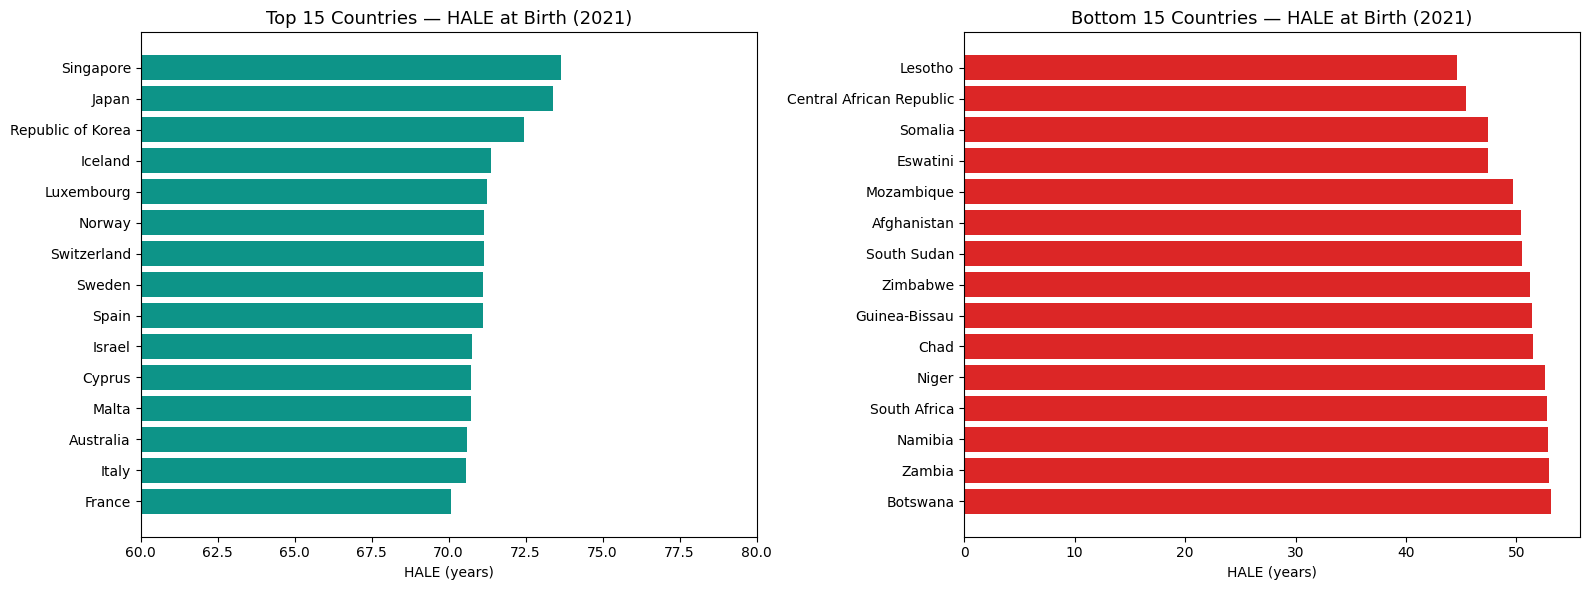

In [15]:
top15 = who_latest.nlargest(15, 'hale').sort_values('hale')
bot15 = who_latest.nsmallest(15, 'hale').sort_values('hale', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top15['country'], top15['hale'], color='#0D9488')
axes[0].set_title('Top 15 Countries — HALE at Birth (2021)', fontsize=13)
axes[0].set_xlabel('HALE (years)')
axes[0].set_xlim(60, 80)

axes[1].barh(bot15['country'], bot15['hale'], color='#DC2626')
axes[1].set_title('Bottom 15 Countries — HALE at Birth (2021)', fontsize=13)
axes[1].set_xlabel('HALE (years)')

plt.tight_layout()
plt.show()

### Q2: What is the HALE gap (years lost to disease/disability) across countries?

A small HALE gap means people spend a higher proportion of their lives in good health — arguably more important than raw life expectancy for quality-of-life comparisons.

In [16]:
print('HALE gap summary (Both sexes, 2021):')
print(who_latest['hale_gap'].describe().round(2))

print('\nSmallest HALE gap (healthiest relative to longevity):')
print(who_latest.nsmallest(10, 'hale_gap')[['country', 'region', 'le', 'hale', 'hale_gap']]
      .to_string(index=False))

print('\nLargest HALE gap (most years lived in poor health):')
print(who_latest.nlargest(10, 'hale_gap')[['country', 'region', 'le', 'hale', 'hale_gap']]
      .to_string(index=False))

HALE gap summary (Both sexes, 2021):
count    185.00
mean       9.40
std        1.32
min        6.53
25%        8.42
50%        9.29
75%       10.42
max       12.49
Name: hale_gap, dtype: float64

Smallest HALE gap (healthiest relative to longevity):
                 country                region    le  hale  hale_gap
                 Somalia Eastern Mediterranean 53.95 47.42      6.53
                 Lesotho                Africa 51.48 44.63      6.85
Central African Republic                Africa 52.31 45.43      6.88
                Eswatini                Africa 54.59 47.47      7.12
           Guinea-Bissau                Africa 58.63 51.45      7.18
                Kiribati       Western Pacific 60.87 53.65      7.22
                Zimbabwe                Africa 58.48 51.25      7.23
                   Niger                Africa 59.97 52.61      7.36
         Solomon Islands       Western Pacific 64.79 57.37      7.42
                 Namibia                Africa 60.36 52.82 

In [17]:
fig = px.scatter(
    who_latest,
    x='le',
    y='hale',
    color='region',
    hover_name='country',
    size='hale_gap',
    size_max=20,
    title='Life Expectancy vs HALE by Country (2021) — bubble size = HALE gap',
    labels={'le': 'Life Expectancy (years)', 'hale': 'Healthy Life Expectancy — HALE (years)'}
)
# Add diagonal reference line (HALE = LE, i.e. zero gap)
mn, mx = who_latest['le'].min(), who_latest['le'].max()
fig.add_shape(type='line', x0=mn, y0=mn, x1=mx, y1=mx,
              line=dict(dash='dash', color='grey', width=1))
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

All countries fall below the diagonal (HALE < LE by definition). Countries in the upper-left area (high LE, modest HALE) spend many years in poor health. The European and Western Pacific clusters are tightly grouped with small gaps, while African countries show both lower HALE and wider gaps.

### Q3: Which regions have the strongest health outcomes — and are they the same regions where sweet-spot cities cluster?

Regional HALE levels establish whether the health quality dimension aligns with the geographic clustering predicted by RQ2 (middle-income regions like Eastern Europe and Southeast Asia as sweet spots).

In [21]:
trend = (
    who[who['sex'] == 'Both sexes']
    .groupby(['year', 'region'])[['hale', 'le']]
    .mean()
    .reset_index()
)

fig = px.line(
    trend,
    x='year',
    y='hale',
    color='region',
    markers=True,
    title='Average HALE at Birth by WHO Region (2000–2021)',
    labels={'hale': 'HALE (years)', 'year': 'Year', 'region': 'WHO Region'}
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [22]:
fig2 = px.line(
    trend,
    x='year',
    y='le',
    color='region',
    markers=True,
    title='Average Life Expectancy at Birth by WHO Region (2000–2021)',
    labels={'le': 'Life Expectancy (years)', 'year': 'Year', 'region': 'WHO Region'}
)
fig2.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig2.show()

Europe and the Western Pacific have the highest HALE, consistent with RQ2's prediction that sweet-spot cities will be found in regions with decent infrastructure. Africa's improvements since 2000 are notable but absolute levels remain low — African cities are unlikely to score well on the health quality dimension. The COVID dip is visible in 2020–2021 across all regions.

### Q4: Does WHO Life Expectancy align with World Bank Life Expectancy?

Data validation before merging sources. If the two diverge significantly for particular countries, those countries need to be flagged in the final analysis.

In [23]:
wb = pd.read_csv('../data/raw/worldbank_wdi_raw.csv', na_values=['..'])

# Reshape WB to long format
year_cols = [c for c in wb.columns if 'YR' in str(c)]
wb_long = wb.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name'],
    value_vars=year_cols,
    var_name='year_raw',
    value_name='value'
)
wb_long['year'] = wb_long['year_raw'].str.extract(r'(\d{4})').astype(int)
wb_le = wb_long[wb_long['Series Name'] == 'Life expectancy at birth, total (years)'][['Country Code','year','value']].rename(
    columns={'Country Code':'country_code','value':'le_wb'}
).dropna()

# WHO both-sexes LE
who_le = who[who['sex'] == 'Both sexes'][['country_code','year','le']].rename(columns={'le':'le_who'})

# Merge
compare = pd.merge(wb_le, who_le, on=['country_code','year'])
print(f'Matched rows: {len(compare)}')

r, p = stats.pearsonr(compare['le_wb'], compare['le_who'])
print(f'Pearson r = {r:.4f},  p = {p:.2e}')

compare['diff'] = (compare['le_wb'] - compare['le_who']).abs()
print(f'\nMean absolute difference: {compare["diff"].mean():.2f} years')
print(f'Max absolute difference:  {compare["diff"].max():.2f} years')

print('\nLargest discrepancies:')
print(compare.nlargest(10,'diff')[['country_code','year','le_wb','le_who','diff']].to_string(index=False))

Matched rows: 2035
Pearson r = 0.9636,  p = 0.00e+00

Mean absolute difference: 1.36 years
Max absolute difference:  23.53 years

Largest discrepancies:
country_code  year  le_wb  le_who   diff
         SSD  2017 35.351   58.88 23.529
         SSD  2016 36.720   59.19 22.470
         CAF  2019 31.530   52.93 21.400
         SSD  2015 39.757   59.28 19.523
         SSD  2014 45.625   59.09 13.465
         CAF  2021 40.279   52.31 12.031
         SOM  2011 32.453   43.81 11.357
         NGA  2019 53.009   63.07 10.061
         NGA  2018 52.669   62.69 10.021
         NGA  2017 52.397   62.36  9.963


In [24]:
fig = px.scatter(
    compare.sample(min(2000, len(compare)), random_state=42),
    x='le_wb',
    y='le_who',
    opacity=0.4,
    title=f'World Bank vs WHO Life Expectancy (r = {r:.3f})',
    labels={'le_wb': 'World Bank LE (years)', 'le_who': 'WHO LE (years)'}
)
mn = min(compare['le_wb'].min(), compare['le_who'].min())
mx = max(compare['le_wb'].max(), compare['le_who'].max())
fig.add_shape(type='line', x0=mn, y0=mn, x1=mx, y1=mx,
              line=dict(dash='dash', color='red', width=1))
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

The two sources agree strongly for most countries (high r), but outliers exist — particularly small Gulf states (Qatar, Bahrain) and some island nations. The World Bank figures for these countries appear to include migrant worker populations differently from WHO estimates. For the merged analysis, **WHO LE is preferred** as the authoritative health source; World Bank data will supply economic indicators.

### Global Map: HALE at Birth (2021)

In [27]:
fig = px.choropleth(
    who_latest,
    locations='country_code',
    color='hale',
    hover_name='country',
    color_continuous_scale='RdYlGn',
    title='Healthy Life Expectancy (HALE) at Birth — 2021 (Both sexes)',
    labels={'hale': 'HALE (years)'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

## Summary

| Finding | Implication for Value-for-Living Analysis |
|---|---|
| East Asian countries (Japan, Singapore, Korea) lead on HALE | High health quality, but also high cost — likely not sweet spots (RQ1) |
| African countries have large HALE gaps despite low LE | Health infrastructure deficit; unlikely to score well on quality (RQ2) |
| European and Southeast Asian regions have small HALE gaps | Strong candidates for sweet-spot regions — decent health, potentially moderate cost (RQ2) |
| WHO and World Bank LE correlate well, with Gulf state exceptions | Safe to merge data sources; flag Gulf countries in final analysis (RQ1/RQ2) |